# Snapshot eval violins - RL vs rule-based control

Per-episode eval metrics of one or more snapshots, **one violin per controller** (RL algorithm
or rule-based strategy), pooled over the eval seeds selected in the next cell. Compared here:
SAC, PPO and DreamerV3 trained on the `sta_lin_battery_only_price` trial (static linear battery,
dynamic day-ahead prices), plus SAC/PPO re-runs at gamma 0.99 instead of the trial's 0.997,
against the rule-based baselines of the `rbc_base` snapshot.

`SNAPSHOTS` (next cell) lists the snapshots; each entry selects which eval kinds are read:

| Struct key | Run directory | Producer | CSVs picked up | Seed metadata |
|---|---|---|---|---|
| `eval-ray` | `runs/eval_<ts>[_seed{N}]/` | Ray RLlib eval (`run_eval_ray.py`) | `eval_results/*_eval/eval_*.csv` | sidecar JSON `"seed"` |
| `eval-sb` | `runs/eval_sb_<ts>[_seed{N}]/` | SB3 eval (`run_eval_sb.py`) | `eval_results/*_eval/eval_*.csv` | sidecar JSON `"seed"` |
| `eval-rbc` | `runs/eval_rbc_<ts>[_seed{N}]/` | Rule-based eval (`run_eval_rule_based.py`) | `eval_results/*_rule_based/<strategy>/episodes.csv` | `args.json` `"resolved_seed"` |

`EVAL_SEEDS` (next cell) selects **which eval seeds feed the violins** — globally, or per
snapshot via that entry's `"seeds"` key. Every `runs/eval_*` directory is scanned, the plain run
and the `_seed{N}` fan-out alike, and each run's seed is read from its own metadata (right-hand
column above) rather than parsed from the directory name — so the un-suffixed default run is
picked up under its real `trial.seed`. The episodes of all selected seeds are pooled into one
violin per controller.

Violins are labelled by rule-based strategy name or by RL algorithm (read from the sidecar JSON
next to each RL eval CSV); with several snapshots the label also carries the entry's 1-based
index in `SNAPSHOTS`, e.g. `sac (ray) (2)`.

Three figures - `total_reward`, `cum_E_kWh` and `cum_price_EUR` - are exported as
`<date>_<time>_out_<i>.pdf` next to this notebook. Requested eval kinds left without CSVs by the
seed selection are reported by the **last cell**.

**Main input:** set `SNAPSHOTS` and `EVAL_SEEDS` in the next cell.

In [1]:
# --- Main input: the snapshots to analyse (paths absolute, or relative to the repo root).
# Each entry selects which eval kinds are picked up (missing keys default to True).
# When several snapshots are plotted, violin labels carry the entry's 1-based index, e.g. "sac (ray) (2)";
# the figure title maps each index to the snapshot's "tag" (optional key, defaults to the
# snapshot's leading YYYYmmdd_HHMMSS timestamp).
# Optional "seeds" key: per-snapshot override of EVAL_SEEDS below (same accepted values).
SNAPSHOTS = [
    {"path": "snapshots/20260703_004926_sta_lin_battery_only_price_sac", "eval-ray": True, "eval-sb": True, "eval-rbc": False},
    {"path": "snapshots/20260704_215559_sta_lin_battery_only_price_sac_gam099", "eval-ray": True, "eval-sb": False, "eval-rbc": False},
    {"path": "snapshots/20260704_144904_sta_lin_battery_only_price_ppo", "eval-ray": True, "eval-sb": False, "eval-rbc": False},
    {"path": "snapshots/20260704_215614_sta_lin_battery_only_price_ppo_gam099", "eval-ray": True, "eval-sb": False, "eval-rbc": False},
    # {"path": "snapshots/20260704_183007_sta_lin_battery_only_price_dreamerv3", "eval-ray": True, "eval-sb": False, "eval-rbc": False},
    # {"path": "snapshots/20260705_153845_sta_lin_battery_only_price_sac_short_rfl", "eval-ray": True, "eval-sb": False, "eval-rbc": False}
    # {"path": "snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base", "eval-ray": False, "eval-sb": False, "eval-rbc": True}
]

# --- Main input: which eval seeds feed the violins. Each seed is one eval run of the same
# checkpoint on a differently drawn set of held-out episodes; the episodes of every selected
# seed are pooled into a single violin per controller.
#   [42]           only the base seed — one 10-episode violin per controller (the pre-seed-sweep default)
#   [42, 43, 91]   these three seeds pooled
#   None           every seed discovered for the snapshot
# The seeds available across the snapshots compared here (produced by
# ./submit_snapshot_eval_seeds.sh at the repo root):
# [42, 43, 44, 45, 46, 70, 71, 91, 103, 140, 141]
EVAL_SEEDS: list[int] | None = [42, 46, 71, 91, 141]


In [2]:
import json
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

EVAL_KINDS = ("eval-ray", "eval-sb", "eval-rbc")


def _find_repo_root() -> Path:
    """Walk upwards from the cwd until the directory containing snapshots/ is found,
    so the notebook runs both from docs/ and from the repo root."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()


def _default_tag(snapshot_dir: Path) -> str:
    """Leading YYYYmmdd_HHMMSS timestamp of the snapshot name — unique and short enough for the title."""
    match = re.match(r"\d{8}_\d{6}", snapshot_dir.name)
    return match.group(0) if match else snapshot_dir.name


def _normalise_seeds(seeds, source: str) -> tuple[int, ...] | None:
    """Seed selection as a tuple of ints; None means 'every seed discovered for that snapshot'."""
    if seeds is None:
        return None
    if isinstance(seeds, int):
        seeds = [seeds]
    normalised = tuple(int(seed) for seed in seeds)
    if not normalised:
        raise ValueError(f"{source}: empty seed selection — use None to keep every discovered seed.")
    return normalised


def _format_seeds(seeds: tuple[int, ...] | None) -> str:
    return "all" if seeds is None else ", ".join(str(seed) for seed in seeds)


snapshot_specs: list[dict] = []
for index, entry in enumerate(SNAPSHOTS, start=1):
    snapshot_dir = Path(entry["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")
    snapshot_specs.append(
        {
            "index": index,
            "dir": snapshot_dir,
            "tag": entry.get("tag", _default_tag(snapshot_dir)),
            # Per-snapshot "seeds" wins over the global EVAL_SEEDS selection
            "seeds": _normalise_seeds(entry.get("seeds", EVAL_SEEDS), f"SNAPSHOTS[{index - 1}]"),
            **{kind: bool(entry.get(kind, True)) for kind in EVAL_KINDS},
        }
    )

if not snapshot_specs:
    raise ValueError("SNAPSHOTS is empty — add at least one snapshot entry.")

MULTI_SNAPSHOT = len(snapshot_specs) > 1  # single-snapshot runs keep the plain labels and PDF names

for spec in snapshot_specs:
    requested = ", ".join(kind for kind in EVAL_KINDS if spec[kind])
    print(f"Snapshot ({spec['index']}): {spec['dir']}  [{requested or 'nothing requested'}]")
    print(f"              eval seeds → {_format_seeds(spec['seeds'])}")
    print(f"              PDF output → {spec['dir'] / 'stat'}")

Snapshot (1): /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260703_004926_sta_lin_battery_only_price_sac  [eval-ray, eval-sb]
              eval seeds → 42, 46, 71, 91, 141
              PDF output → /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260703_004926_sta_lin_battery_only_price_sac/stat
Snapshot (2): /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_215559_sta_lin_battery_only_price_sac_gam099  [eval-ray]
              eval seeds → 42, 46, 71, 91, 141
              PDF output → /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_215559_sta_lin_battery_only_price_sac_gam099/stat
Snapshot (3): /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_144904_sta_lin_battery_only_price_ppo  [eval-ray]
              eval seeds → 42, 46, 71, 91, 141
              PDF output → /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_144904_sta_lin_battery_only_price_ppo/stat
Snapshot (4): /hkfs/home/haicore/iai/dj0397/AdvBui

## Output naming

Everything saved here lands next to the notebook as `<date>_<time>_out_<i>.<file format>`:
one timestamp per notebook run, `out_index` counting up per saved artefact, so no run
overwrites an earlier one.

In [3]:
from datetime import datetime
from pathlib import Path

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
OUT_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(file_format: str) -> Path:
    """Next '<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    return OUT_DIR / f"{OUT_RUN_STAMP}_out_{out_index}.{file_format}"


## Discover the eval CSVs

One record per CSV, restricted to the eval kinds each `SNAPSHOTS` entry requests and to the
seeds its selection keeps. Every `runs/eval_*` directory is scanned — the plain run and the
`_seed{N}` fan-out alike — and each record's seed comes from that run's own metadata (RL:
the sidecar JSON's `"seed"`; rule-based: `args.json`'s `"resolved_seed"`), so a run is never
classified by its directory name. Records whose seed cannot be read are dropped with a warning.

RL CSVs take their violin name from the `algorithm` field of the sidecar JSON with the same stem
(e.g. `eval_checkpoint_000174_….json`), rule-based ones from their strategy directory;
`pv_surplus_charge` is dropped entirely. Records sharing a name within a snapshot are pooled
into one violin; two checkpoints of the same algorithm stay apart via a `[ckpt N]` suffix.

A snapshot can hold two runs of the same controller at the same seed (the gamma-0.99 snapshots
have both an un-suffixed run and a `_seed42` sweep run at seed 42). Only one of them is kept —
the un-suffixed run first — so a seed never enters a violin twice; the dropped run is printed.

Eval kinds left with no CSVs by the seed selection are collected in `missing_eval_logs` and
reported by the last cell.

In [4]:
METRICS = ("total_reward", "cum_E_kWh", "cum_price_EUR")

# Rule-based strategy directories to leave out of the figures entirely
EXCLUDED_STRATEGIES = {"pv_surplus_charge"}

# Seed fan-out suffix written by submit_snapshot_eval_seeds.sh (e.g. "eval_20260706_120000_seed42").
# Only used to order runs for the duplicate-seed tie-break below — the seed itself is always read
# from the run's own metadata.
SEED_SUFFIX_REGEX = re.compile(r"_seed(-?\d+)$")

# Requested-but-absent (snapshot, eval kind, seed) combinations; the last notebook cell reports these.
missing_eval_logs: list[str] = []


def _sanitise_label(name: str) -> str:
    """Underscores read poorly on the x-axis — display labels use spaces instead."""
    return name.replace("_", " ")


def _sidecar_payload(csv_path: Path) -> dict:
    """Ray/SB3 eval sidecar JSON (same stem as the CSV): carries "algorithm" and the run's "seed"."""
    sidecar = csv_path.with_suffix(".json")
    if not sidecar.is_file():
        return {}
    try:
        return json.loads(sidecar.read_text())
    except (json.JSONDecodeError, OSError):
        return {}


def _rbc_args_payload(csv_path: Path) -> dict:
    """Rule-based args.json (one level above the per-strategy dir): carries "resolved_seed"."""
    args_path = csv_path.parent.parent / "args.json"
    if not args_path.is_file():
        return {}
    try:
        return json.loads(args_path.read_text())
    except (json.JSONDecodeError, OSError):
        return {}


def _rl_eval_records(run_dir: Path, kind: str) -> list[dict]:
    records = []
    for csv_path in sorted(run_dir.glob("eval_results/*_eval/eval_*.csv")):
        payload = _sidecar_payload(csv_path)
        checkpoint = re.search(r"checkpoint_(\d+)", csv_path.name)
        records.append(
            {
                "base_label": f"{_sanitise_label(payload.get('algorithm') or 'unknown')} ({kind})",
                # Distinguishes two checkpoints of one algorithm; equal across the seeds that pool together
                "variant": f"ckpt {int(checkpoint.group(1))}" if checkpoint else "",
                "kind": kind,
                "seed": payload.get("seed"),
                "run": run_dir.name,
                "csv": csv_path,
            }
        )
    return records


def _rule_based_records(run_dir: Path) -> list[dict]:
    records = []
    for csv_path in sorted(run_dir.glob("eval_results/*_rule_based/*/episodes.csv")):
        if csv_path.parent.name in EXCLUDED_STRATEGIES:
            continue
        records.append(
            {
                "base_label": _sanitise_label(csv_path.parent.name),
                "variant": "",
                "kind": "rule-based",
                "seed": _rbc_args_payload(csv_path).get("resolved_seed"),
                "run": run_dir.name,
                "csv": csv_path,
            }
        )
    return records


def _records_for_kind(run_dir: Path, eval_kind: str) -> list[dict]:
    """Records of the one run directory `run_dir`, read according to its eval kind."""
    if eval_kind == "eval-rbc":
        return _rule_based_records(run_dir)
    return _rl_eval_records(run_dir, "sb3" if eval_kind == "eval-sb" else "ray")


def _run_dir_eval_kind(run_dir: Path) -> str:
    """Map a runs/eval_* directory to its SNAPSHOTS struct key."""
    if run_dir.name.startswith("eval_rbc_"):
        return "eval-rbc"
    if run_dir.name.startswith("eval_sb_"):
        return "eval-sb"
    return "eval-ray"


def _run_dir_order(run_dir: Path) -> tuple[bool, str]:
    """Un-suffixed runs before the _seed{N} fan-out, so the plain run wins a duplicate-seed tie."""
    return (SEED_SUFFIX_REGEX.search(run_dir.name) is not None, run_dir.name)


def _drop_duplicate_seed_runs(records: list[dict], snapshot_name: str) -> list[dict]:
    """Keep one record per (controller, seed) — a seed must not enter the same violin twice."""
    kept: dict[tuple, dict] = {}
    unique_records = []
    for record in records:
        key = (record["base_label"], record["variant"], record["seed"])
        if key in kept:
            print(
                f"note: {snapshot_name}: '{record['base_label']}' seed {record['seed']} evaluated twice — "
                f"keeping {kept[key]['run']}, dropping {record['run']}"
            )
            continue
        kept[key] = record
        unique_records.append(record)
    return unique_records


def discover_eval_csvs(spec: dict) -> list[dict]:
    """Scan <snapshot>/runs/eval_* for the eval kinds `spec` requests, keeping the seeds it selects.

    Every run directory is read (plain and _seed{N} alike); the seed comes from each run's own
    metadata. Requested-but-absent kinds and seeds are appended to `missing_eval_logs`."""
    records_per_kind: dict[str, list[dict]] = {kind: [] for kind in EVAL_KINDS}
    for run_dir in sorted((spec["dir"] / "runs").glob("eval_*"), key=_run_dir_order):
        eval_kind = _run_dir_eval_kind(run_dir)
        if not spec[eval_kind]:
            continue
        records_per_kind[eval_kind].extend(_records_for_kind(run_dir, eval_kind))

    selected_seeds = spec["seeds"]
    records: list[dict] = []
    for eval_kind in EVAL_KINDS:
        if not spec[eval_kind]:
            continue
        kind_records = records_per_kind[eval_kind]
        for record in kind_records:
            if record["seed"] is None:
                print(f"note: {spec['dir'].name}: no seed metadata for {record['run']} / {record['csv'].name} — dropped")
        kind_records = [record for record in kind_records if record["seed"] is not None]

        absent_seeds: list[int] = []
        if selected_seeds is not None:
            evaluated_seeds = {record["seed"] for record in kind_records}
            kind_records = [record for record in kind_records if record["seed"] in selected_seeds]
            absent_seeds = [seed for seed in selected_seeds if seed not in evaluated_seeds]
        kind_records = _drop_duplicate_seed_runs(kind_records, spec["dir"].name)

        if not kind_records:
            # Covers the absent seeds too — no per-seed line on top of "nothing at all"
            missing_eval_logs.append(
                f"{spec['dir'].name}: '{eval_kind}' requested but no eval CSVs found "
                f"for seed selection {_format_seeds(selected_seeds)}"
            )
        elif absent_seeds:
            missing_eval_logs.append(
                f"{spec['dir'].name}: '{eval_kind}' has no eval run for seed(s) {absent_seeds} — "
                "the remaining selected seeds are plotted"
            )
        records.extend(kind_records)

    for record in records:
        record["snapshot_index"] = spec["index"]
        record["snapshot"] = spec["dir"].name
    return records


def _assign_violin_labels(records: list[dict]) -> None:
    """One label per (snapshot, controller); records of different seeds share it and pool into one violin."""
    variants_per_controller: dict[tuple, set[str]] = defaultdict(set)
    for record in records:
        variants_per_controller[(record["snapshot_index"], record["base_label"])].add(record["variant"])
    for record in records:
        label = record["base_label"]
        if record["variant"] and len(variants_per_controller[(record["snapshot_index"], record["base_label"])]) > 1:
            label = f"{label} [{record['variant']}]"
        if MULTI_SNAPSHOT:
            label = f"{label} ({record['snapshot_index']})"
        record["label"] = label


def _display_path(csv_path: Path) -> str:
    try:
        return str(csv_path.relative_to(REPO_ROOT))
    except ValueError:
        return str(csv_path)


eval_records: list[dict] = []
for spec in snapshot_specs:
    eval_records.extend(discover_eval_csvs(spec))
_assign_violin_labels(eval_records)
eval_records.sort(key=lambda record: (record["snapshot_index"], record["label"], record["seed"]))
if not eval_records:
    raise FileNotFoundError(
        f"No eval CSVs found for any requested snapshot/eval-kind/seed combination: {missing_eval_logs}"
    )

pd.DataFrame(
    {
        "label": record["label"],
        "kind": record["kind"],
        "seed": record["seed"],
        "snapshot_index": record["snapshot_index"],
        "snapshot": record["snapshot"],
        "csv": _display_path(record["csv"]),
    }
    for record in eval_records
)

note: 20260704_215559_sta_lin_battery_only_price_sac_gam099: 'sac (ray)' seed 42 evaluated twice — keeping eval_20260705_231620, dropping eval_20260706_115312_seed42
note: 20260704_215614_sta_lin_battery_only_price_ppo_gam099: 'ppo (ray)' seed 42 evaluated twice — keeping eval_20260705_231622, dropping eval_20260706_115322_seed42


,label,kind,seed,snapshot_index,snapshot,csv
0,sac (ray) (1),ray,42,1,20260703_004926_sta_lin_battery_only_price_sac,snapshots/20260703_004926_sta_lin_battery_only...
1,sac (ray) (1),ray,46,1,20260703_004926_sta_lin_battery_only_price_sac,snapshots/20260703_004926_sta_lin_battery_only...
2,sac (ray) (1),ray,71,1,20260703_004926_sta_lin_battery_only_price_sac,snapshots/20260703_004926_sta_lin_battery_only...
3,sac (ray) (1),ray,91,1,20260703_004926_sta_lin_battery_only_price_sac,snapshots/20260703_004926_sta_lin_battery_only...
4,sac (ray) (1),ray,141,1,20260703_004926_sta_lin_battery_only_price_sac,snapshots/20260703_004926_sta_lin_battery_only...
5,sac (ray) (2),ray,42,2,20260704_215559_sta_lin_battery_only_price_sac...,snapshots/20260704_215559_sta_lin_battery_only...
6,sac (ray) (2),ray,46,2,20260704_215559_sta_lin_battery_only_price_sac...,snapshots/20260704_215559_sta_lin_battery_only...
7,sac (ray) (2),ray,71,2,20260704_215559_sta_lin_battery_only_price_sac...,snapshots/20260704_215559_sta_lin_battery_only...
8,sac (ray) (2),ray,91,2,20260704_215559_sta_lin_battery_only_price_sac...,snapshots/20260704_215559_sta_lin_battery_only...
9,sac (ray) (2),ray,141,2,20260704_215559_sta_lin_battery_only_price_sac...,snapshots/20260704_215559_sta_lin_battery_only...


## Load per-episode metrics

The CSVs are concatenated into one frame with a row per episode, the three metrics as columns
and the run's eval seed kept alongside — so a violin is the pool of every selected seed's
episodes for that controller. RL violins are ordered first on the x-axis, rule-based strategies
after them; a CSV missing a metric column is simply absent from that metric's figure. The table
(`violin_stats`) shows the pooled seed count, episode count and the per-metric mean **and sample
standard deviation** (`ddof=1`, pandas' default) for each violin (each eval run contributes 10
episodes). The std is taken over the pooled episodes, so it mixes episode-to-episode and
seed-to-seed variation — the same spread the violin draws.

In [5]:
frames = []
for record in eval_records:
    csv_frame = pd.read_csv(record["csv"])
    missing = [metric for metric in METRICS if metric not in csv_frame.columns]
    if missing:
        print(f"note: '{record['label']}' seed {record['seed']} has no {missing} column(s) — skipped in those figures")
    frame = csv_frame[[metric for metric in METRICS if metric in csv_frame.columns]].copy()
    frame["label"] = record["label"]
    frame["kind"] = record["kind"]
    frame["eval_seed"] = record["seed"]  # the run's seed, so a violin's pooled seeds stay traceable
    frame["group"] = "RBC" if record["kind"] == "rule-based" else "RL"
    frames.append(frame)

episodes = pd.concat(frames, ignore_index=True)

# RL violins first, then the rule-based strategies; one x position per label even when several
# eval seeds pool into it
label_order = list(
    dict.fromkeys(
        [record["label"] for record in eval_records if record["kind"] != "rule-based"]
        + [record["label"] for record in eval_records if record["kind"] == "rule-based"]
    )
)

# Mean and sample std (ddof=1) over the pooled episodes of every selected seed — the spread of the
# violin itself, i.e. episode-to-episode variation including the seed-to-seed differences.
violin_stats = episodes.groupby(["label", "kind"], sort=False).agg(
    seeds=("eval_seed", "nunique"),
    episodes=("total_reward", "size"),
    **{
        f"{statistic}_{metric}": (metric, statistic)
        for metric in METRICS
        for statistic in ("mean", "std")
    },
)
violin_stats

,,seeds,episodes,mean_total_reward,std_total_reward,mean_cum_E_kWh,std_cum_E_kWh,mean_cum_price_EUR,std_cum_price_EUR
label,kind,,,,,,,,
sac (ray) (1),ray,5,50,13.384092,4.096828,42.930471,7.926057,-3.626587,1.929744
sac (ray) (2),ray,5,50,14.036036,4.054305,46.775107,8.734836,-4.100081,1.919775
ppo (ray) (3),ray,5,50,12.771255,4.173115,47.193828,8.594326,-3.819266,1.540163
ppo (ray) (4),ray,5,50,12.680561,3.757495,47.193828,8.594326,-3.860819,1.674986


## Violin plots

One violin per controller — pooling the episodes of every selected eval seed — with the
individual episodes overlaid as dots; blue = RL policies, green = rule-based. Each violin
carries a red **mean** dot and a dashed **median** line. Every figure is saved as
`<date>_<time>_out_<i>.pdf` next to this notebook.

Widening `EVAL_SEEDS` widens the sample behind each violin (10 episodes per seed), so the
distributions cover the seed-to-seed spread of the held-out draws instead of a single draw; the
per-violin means for the current selection are in the table above.

In [6]:
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid", context="paper")

# Figure geometry in inches. The figures are embedded at their natural size, so the canvas is
# drawn at the width it should occupy on the page rather than being scaled down by LaTeX
# (which shrinks the fonts with it). A4 text width with 2.5 cm margins is ~6.3 in / 16 cm;
# the default below sits just under that so the figure does not span the full text width.
# The width includes the legend column on the right: tight_layout counts the legend, so the
# axes shrink to make room for it instead of the export growing past FIGURE_WIDTH_IN.
FIGURE_WIDTH_IN = 5.5
FIGURE_HEIGHT_IN = 2.8
FIGURE_WIDTH_PER_VIOLIN_IN = 1.05  # only widens the figure past FIGURE_WIDTH_IN for many violins

GROUP_COLORS = {"RL": "#75aef4", "RBC": "#89f0cc"}
METRIC_LABELS = {
    "total_reward": "Return",
    "cum_E_kWh": "Net energy [kWh]",
    "cum_price_EUR": "Cumulative energy price [EUR]",
}

# Stat markers drawn on top of each violin (replaces seaborn's faint inner box)
MEAN_COLOR = "#e34948"  # red dot
MEDIAN_COLOR = "#1a1a19"  # narrow dashed line
MEDIAN_DASH = (0, (4, 2))


def _draw_stat_markers(ax, data: pd.DataFrame, metric: str) -> None:
    """Overlay the mean (red dot) and median (narrow dashed line) of each violin."""
    stats = data.groupby("label")[metric].agg(["mean", "median"])
    for x_position, label in enumerate(label_order):
        if label not in stats.index:
            continue
        row = stats.loc[label]
        ax.hlines(
            row["median"], x_position - 0.23, x_position + 0.23,
            color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, zorder=5,
        )
        ax.scatter(
            x_position, row["mean"],
            color=MEAN_COLOR, s=18, edgecolor="white", linewidth=0.5, zorder=6,
        )


def violin_for_metric(metric: str) -> None:
    """Draw one violin per controller — the episodes of the selected eval seeds pooled — for
    `metric`, and export the figure as a PDF next to this notebook."""
    data = episodes.dropna(subset=[metric]) if metric in episodes.columns else episodes.iloc[0:0]
    if data.empty:
        print(f"no data for '{metric}' — figure skipped")
        return

    # Legend entries follow the data: a group with no violin in this figure is not drawn
    present_groups = [group for group in GROUP_COLORS if group in set(data["group"])]

    figure_width = max(FIGURE_WIDTH_IN, FIGURE_WIDTH_PER_VIOLIN_IN * len(label_order))
    fig, ax = plt.subplots(figsize=(figure_width, FIGURE_HEIGHT_IN))
    sns.violinplot(
        data=data,
        x="label",
        y=metric,
        hue="group",
        order=label_order,
        hue_order=present_groups,
        palette={group: GROUP_COLORS[group] for group in present_groups},
        dodge=False,  # hue only colours the violins; every label keeps its own x position
        density_norm="area",
        # cut=0,  # do not extrapolate the KDE beyond observed episode values
        inner=None,  # the stat markers below replace seaborn's faint inner box
        linewidth=1.0,
        saturation=1.0,
        ax=ax,
    )
    sns.stripplot(
        data=data, x="label", y=metric, order=label_order,
        color="0.1", size=3, alpha=0.6, jitter=0.08, ax=ax,
    )
    _draw_stat_markers(ax, data, metric)

    ax.set_xlabel("")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    ax.grid(axis="x", visible=False)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    group_handles, group_labels = ax.get_legend_handles_labels()
    stat_handles = [
        Line2D([], [], color=MEAN_COLOR, marker="o", linestyle="none", markersize=5,
            markeredgewidth=0.5, label="mean"),
        Line2D([], [], color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, label="median"),
    ]
    # Legend outside the axes so it never covers a violin
    ax.legend(
        handles=group_handles + stat_handles,
        labels=group_labels + [handle.get_label() for handle in stat_handles],
        title="", frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
    )
    sns.despine(ax=ax)
    fig.tight_layout()

    pdf_path = next_out_path("pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"saved {pdf_path}  ({metric})")
    plt.show()

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/20260804_001809_out_1.pdf  (total_reward)


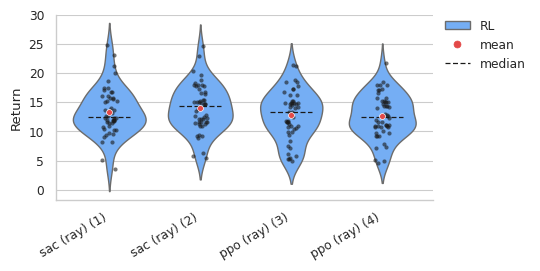

In [7]:
violin_for_metric("total_reward")

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/20260804_001809_out_2.pdf  (cum_E_kWh)


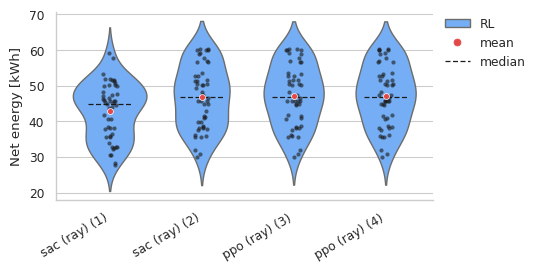

In [8]:
violin_for_metric("cum_E_kWh")

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/20260804_001809_out_3.pdf  (cum_price_EUR)


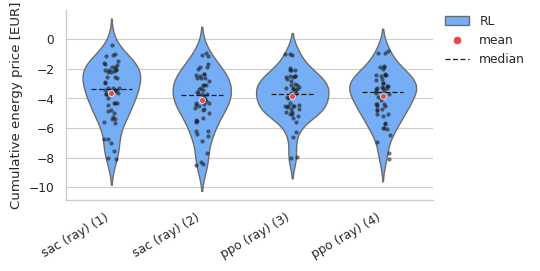

In [9]:
violin_for_metric("cum_price_EUR")

## Missing requested evals

One log line per requested-but-absent combination: an eval kind a `SNAPSHOTS` entry asked for
that discovery found no CSVs for (missing or empty `runs/eval_*` directory), and any seed of the
selection that snapshot was never evaluated with.

In [10]:
if missing_eval_logs:
    for log_line in missing_eval_logs:
        print(f"WARNING: {log_line}")
else:
    print("All requested eval kinds and seeds were found in every snapshot.")